 Tahap 1: Persiapan Lingkungan dan Import Library

Install Library

In [1]:
# Install library jika belum tersedia
!pip install scikit-learn pandas numpy seaborn matplotlib imbalanced-learn requests kagglehub mlflow joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
import mlflow
import mlflow.sklearn
import joblib

from imblearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    RFE,
    SelectFromModel
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

c:\Users\ASUS\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tahap 2: Pengumpulan dan Load Dataset

In [31]:
# Download Dataset IoT Vulnerability Dataset
url = "https://data.mendeley.com/public-files/datasets/7m58kxs742/files/4d57de6a-a140-4607-bf38-146899f1a723/file_downloaded"
file_name = "Preprocessed_Balanced_dataset.csv"

print(f"Downloading {file_name}...")
response = requests.get(url)

if response.status_code == 200:
    with open(file_name, "wb") as f:
        f.write(response.content)
    print(f"{file_name} berhasil diunduh.\n")
else:
    print(f"Gagal mengunduh {file_name}. Status code: {response.status_code}\n")

# Load Dataset
df = pd.read_csv(file_name)
display(df.head())

Preprocessed_Balanced_dataset.csv berhasil diunduh.



,dur,Protocol,Length,Source Host,Destination Host,Sender IP address,Target IP address,Opcode,checksom(ICMP),Sequence Number (LE),...,Flags.1,Packet Length (encrypted),Direction,TCP Option - Maximum segment size,Data,Checksum,CDATA,Label,Attack_Category,Attack_sub_category
0,0.143546,1,42,1,1,4,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
1,0.000679,1,42,1,1,3,4,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
2,0.010981,1,42,1,1,11,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
3,0.000684,1,42,1,1,3,24,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
4,0.012461,1,42,1,1,12,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning


Tahap 3: Exploratory Data Analysis (EDA)

Informasi & Statistik Dataset:

In [3]:
df.info(), df.describe(), df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 88 columns):
 #   Column                                                      Non-Null Count    Dtype  
---  ------                                                      --------------    -----  
 0   dur                                                         1048575 non-null  float64
 1   Protocol                                                    1048575 non-null  int64  
 2   Length                                                      1048575 non-null  int64  
 3   Source Host                                                 1048575 non-null  int64  
 4   Destination Host                                            1048575 non-null  int64  
 5   Sender IP address                                           1048575 non-null  int64  
 6   Target IP address                                           1048575 non-null  int64  
 7   Opcode                                                      104

(None,
                 dur      Protocol        Length   Source Host  \
 count  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06   
 mean   4.171936e-02  2.142777e+01  1.122461e+02  5.407739e+04   
 std    1.914513e-01  1.107721e+01  2.385786e+02  3.109492e+04   
 min   -1.606545e-02  0.000000e+00  4.200000e+01  0.000000e+00   
 25%    9.790000e-05  1.100000e+01  4.200000e+01  5.746800e+04   
 50%    3.162750e-04  3.000000e+01  6.000000e+01  6.067100e+04   
 75%    2.474092e-03  3.000000e+01  7.400000e+01  6.067700e+04   
 max    7.973827e+00  3.500000e+01  5.858000e+03  1.449670e+05   
 
        Destination Host  Sender IP address  Target IP address        Opcode  \
 count      1.048575e+06       1.048575e+06       1.048575e+06  1.048575e+06   
 mean       3.146737e+03       1.291301e+00       1.740716e+00  9.528074e-01   
 std        1.511347e+03       1.921420e+00       4.199544e+00  5.890998e-01   
 min        0.000000e+00       0.000000e+00       0.000000e+00  0.000000e+00 

Visualisasi Distribusi Label:

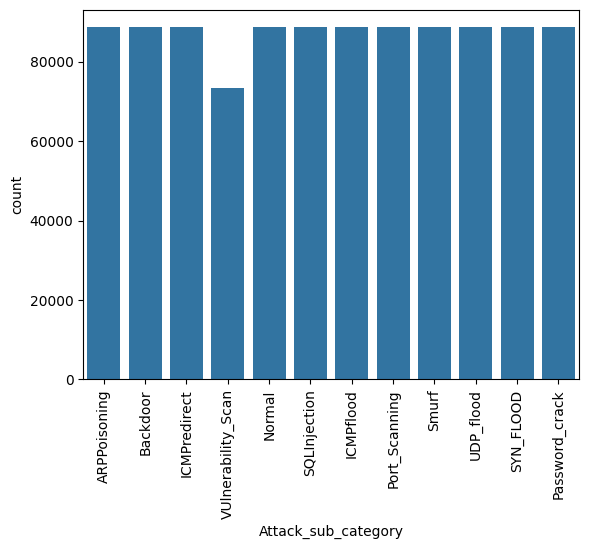

In [4]:
sns.countplot(data=df ,x='Attack_sub_category')
plt.xticks(rotation=90)
plt.show()

Analisis Korelasi:

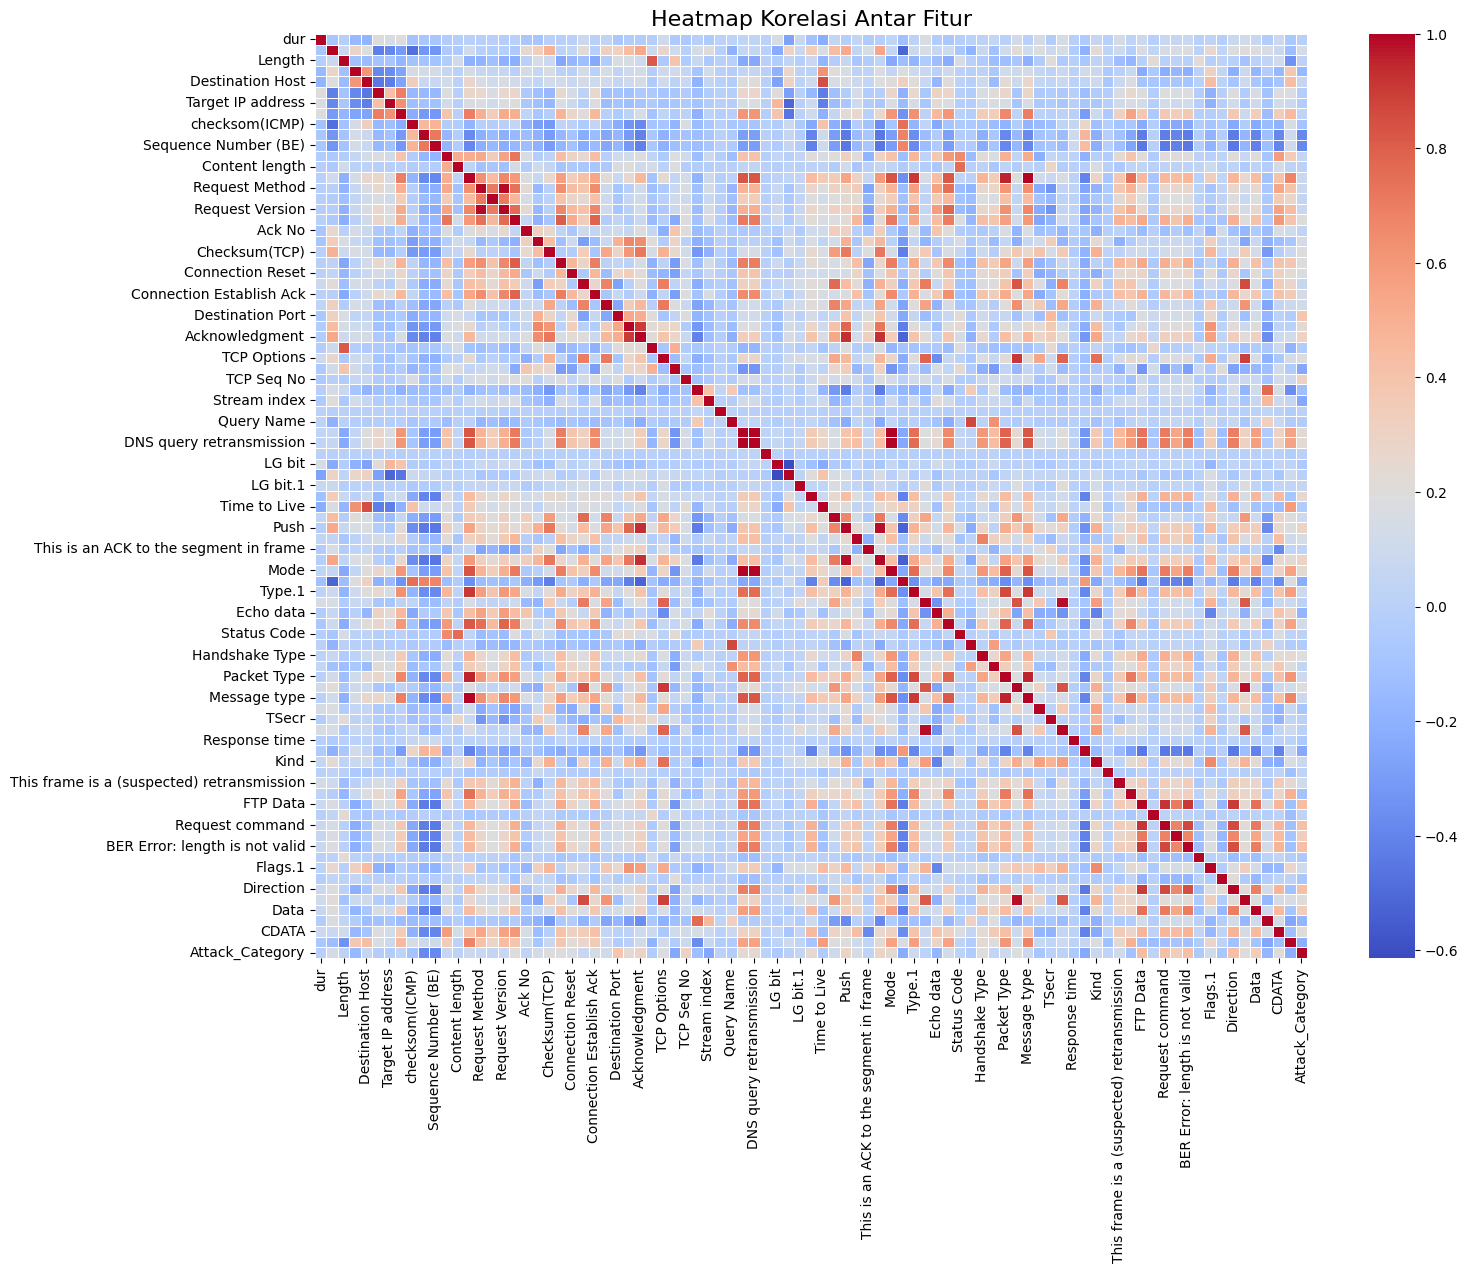

In [5]:
# Analisis Korelasi Antar Fitur

# Menghitung matriks korelasi
corr_matrix = df.corr(numeric_only=True)

# Membuat visualisasi heatmap
plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=False,      # ubah menjadi True jika ingin menampilkan angka korelasi
    linewidths=0.5
)

plt.title("Heatmap Korelasi Antar Fitur", fontsize=16)
plt.show()

 Tahap 4: Preprocessing Data

In [6]:
# ================================
# Preprocessing
# ================================

# Target column
target_column = df.columns[-1]

# Label Encoding target
le = LabelEncoder()
df[target_column] = le.fit_transform(df[target_column])

# Pisahkan fitur & target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Ambil hanya fitur numerik
X = X.select_dtypes(include=['int64', 'float64'])

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Tahap 5: Implementasi Pipeline & Cross Validation (Metode Inti)

A. Pipeline 1: Filter Method (Contoh: SelectKBest)

In [7]:
pipeline_filter = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=10)),
    ('model', RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

B. Pipeline 2: Wrapper Method

In [8]:
pipeline_wrapper = Pipeline([
    ('scaler', StandardScaler()),
    
    ('feature_selection', RFE(
        estimator=RandomForestClassifier(
            n_estimators=10,
            max_depth=5,
            random_state=42,
            n_jobs=1
        ),
        n_features_to_select=10
    )),
    
    ('model', RandomForestClassifier(
        n_estimators=10,
        max_depth=5,
        random_state=42,
        n_jobs=1
    ))
])

C. Pipeline 3: Embedded Method (Contoh: SelectFromModel)

In [9]:
pipeline_embedded = Pipeline([
    ('scaler', StandardScaler()),
    
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(
            n_estimators=5,
            max_depth=3,
            random_state=42,
            n_jobs=1
        )
    )),
    
    ('model', RandomForestClassifier(
        n_estimators=20,
        max_depth=5,
        random_state=42,
        n_jobs=1
    ))
])

 Tahap 6: Evaluasi Cross Validation

In [10]:
# ============================================
# SETUP CROSS VALIDATION
# ============================================
from sklearn.model_selection import cross_validate, StratifiedKFold

# Cross Validation Strategy
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

In [11]:
#filter
cv_results_filter = cross_validate(
    pipeline_filter,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

print("FILTER METHOD")
print("Accuracy :", cv_results_filter['test_accuracy'].mean())
print("Precision:", cv_results_filter['test_precision_macro'].mean())
print("Recall   :", cv_results_filter['test_recall_macro'].mean())
print("F1 Score :", cv_results_filter['test_f1_macro'].mean())


FILTER METHOD
Accuracy : 0.8290239134062893
Precision: 0.9088062717624654
Recall   : 0.8275844722630783
F1 Score : 0.8080350506015102


In [12]:
cv_results_wrapper = cross_validate(
    pipeline_wrapper,
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring=scoring,
    n_jobs=2
)

print("\nWRAPPER METHOD")
print("Accuracy :", cv_results_wrapper['test_accuracy'].mean())
print("Precision:", cv_results_wrapper['test_precision_macro'].mean())
print("Recall   :", cv_results_wrapper['test_recall_macro'].mean())
print("F1 Score :", cv_results_wrapper['test_f1_macro'].mean())


WRAPPER METHOD
Accuracy : 0.9067782466680973
Precision: 0.8890303119070916
Recall   : 0.8968378460357872
F1 Score : 0.8718147327726459


In [13]:
# Embedded Method
cv_results_embedded = cross_validate(
    pipeline_embedded,
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
    n_jobs=1
)

print("\nEMBEDDED METHOD")
print("Accuracy :", cv_results_embedded['test_accuracy'].mean())
print("Precision:", cv_results_embedded['test_precision_macro'].mean())
print("Recall   :", cv_results_embedded['test_recall_macro'].mean())
print("F1 Score :", cv_results_embedded['test_f1_macro'].mean())


EMBEDDED METHOD
Accuracy : 0.9626016260162601
Precision: 0.9725413809534665
Recall   : 0.9625426096455726
F1 Score : 0.9606544589065237


      Metric    Filter   Wrapper  Embedded
0   Accuracy  0.829024  0.906778  0.962602
1  Precision  0.908806  0.889030  0.972541
2     Recall  0.827584  0.896838  0.962543
3   F1 Score  0.808035  0.871815  0.960654


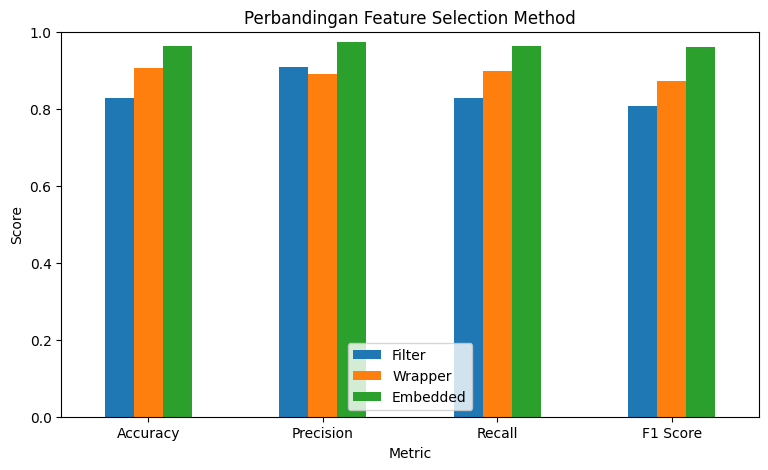

In [14]:
# Perbandingan semua metode feature selection
results_compare = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    
    'Filter': [
        cv_results_filter['test_accuracy'].mean(),
        cv_results_filter['test_precision_macro'].mean(),
        cv_results_filter['test_recall_macro'].mean(),
        cv_results_filter['test_f1_macro'].mean()
    ],
    
    'Wrapper': [
        cv_results_wrapper['test_accuracy'].mean(),
        cv_results_wrapper['test_precision_macro'].mean(),
        cv_results_wrapper['test_recall_macro'].mean(),
        cv_results_wrapper['test_f1_macro'].mean()
    ],
    
    'Embedded': [
        cv_results_embedded['test_accuracy'].mean(),
        cv_results_embedded['test_precision_macro'].mean(),
        cv_results_embedded['test_recall_macro'].mean(),
        cv_results_embedded['test_f1_macro'].mean()
    ]
})

# Tampilkan tabel
print(results_compare)

# Bar Chart
results_compare.plot(
    x='Metric',
    kind='bar',
    figsize=(9,5)
)

plt.title('Perbandingan Feature Selection Method')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0,1)

plt.show()

Tahap 7: Hyperparameter Tuning

RandomizedSearchCV

In [15]:
from sklearn.model_selection import RandomizedSearchCV

# Parameter tuning
param_dist = {
    'feature_selection__estimator__n_estimators': [5, 10, 20],
    'feature_selection__estimator__max_depth': [3, 5, 7],

    'model__n_estimators': [5, 10, 20],
    'model__max_depth': [3, 5, 7]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=pipeline_embedded,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=1
)

# Training tuning
random_search.fit(X_train, y_train)

# Hasil terbaik
print("Best Score :", random_search.best_score_)
print("Best Params:", random_search.best_params_)

Best Score : 0.9568998402593997
Best Params: {'model__n_estimators': 10, 'model__max_depth': 5, 'feature_selection__estimator__n_estimators': 5, 'feature_selection__estimator__max_depth': 5}


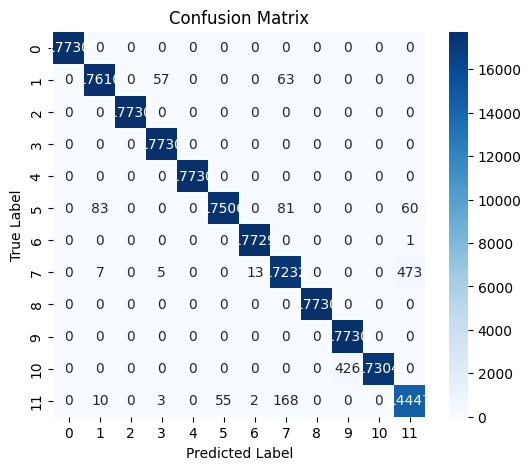


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17730
           1       0.99      0.99      0.99     17730
           2       1.00      1.00      1.00     17730
           3       1.00      1.00      1.00     17730
           4       1.00      1.00      1.00     17730
           5       1.00      0.99      0.99     17730
           6       1.00      1.00      1.00     17730
           7       0.98      0.97      0.98     17730
           8       1.00      1.00      1.00     17730
           9       0.98      1.00      0.99     17730
          10       1.00      0.98      0.99     17730
          11       0.96      0.98      0.97     14685

    accuracy                           0.99    209715
   macro avg       0.99      0.99      0.99    209715
weighted avg       0.99      0.99      0.99    209715


Model berhasil disimpan sebagai pipeline_terbaik.pkl


In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Gunakan model terbaik hasil tuning
best_model = random_search.best_estimator_

# Prediksi data test
y_pred = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

# Classification Report
print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

# Simpan model terbaik
joblib.dump(best_model, 'pipeline_terbaik.pkl')

print("\nModel berhasil disimpan sebagai pipeline_terbaik.pkl")

Tahap 9: Script Tracking MLflow (mlflow.py)

In [17]:
print(df.columns)

Index(['dur', 'Protocol', 'Length', 'Source Host', 'Destination Host',
       'Sender IP address', 'Target IP address', 'Opcode', 'checksom(ICMP)',
       'Sequence Number (LE)', 'Sequence Number (BE)', 'File Data',
       'Content length', 'Request URI Query', 'Request Method',
       'Full Request URI', 'Request Version', 'Response', 'Ack No',
       'Ack No (RAW)', 'Checksum(TCP)', 'Connection Finish ',
       'Connection Reset', 'Connection Establish Request',
       'Connection Establish Ack', 'Source Port', 'Destination Port',
       'TCPFlags', 'Acknowledgment', 'TCP Segment Length', 'TCP Options',
       'TCP Payload', 'TCP Seq No', 'Src or Drc port', 'Stream index',
       'Time since previous frame', 'Query Name', 'DNS retransmission',
       'DNS query retransmission', 'DNS query retransmission in', 'LG bit',
       'IG bit', 'LG bit.1', 'Duplicate IP address configured', 'Time to Live',
       'Conversation completeness', 'Push', 'Content Type',
       'This is an ACK to th

In [24]:
# ================================
# MLflow Tracking
# ================================

import mlflow
import mlflow.sklearn
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

mlflow.set_experiment("IoT_Vulnerability_Classification")

with mlflow.start_run():

    # Training model terbaik
    best_model.fit(X_train, y_train)

    # Prediksi
    y_pred = best_model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    # Log parameter terbaik
    mlflow.log_params(best_model.get_params())

    # Log metrics
    mlflow.log_metrics({
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    })

    # Log model
    mlflow.sklearn.log_model(
        sk_model=best_model,
        artifact_path="model"
    )

    # Simpan model
    joblib.dump(
        best_model,
        "pipeline_terbaik.pkl"
    )

    print("Model berhasil disimpan.\n")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

2026/05/26 13:34:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 13:34:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model berhasil disimpan.

Accuracy  : 0.9928
Precision : 0.9925
Recall    : 0.9927
F1 Score  : 0.9925

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17730
           1       0.99      0.99      0.99     17730
           2       1.00      1.00      1.00     17730
           3       1.00      1.00      1.00     17730
           4       1.00      1.00      1.00     17730
           5       1.00      0.99      0.99     17730
           6       1.00      1.00      1.00     17730
           7       0.98      0.97      0.98     17730
           8       1.00      1.00      1.00     17730
           9       0.98      1.00      0.99     17730
          10       1.00      0.98      0.99     17730
          11       0.96      0.98      0.97     14685

    accuracy                           0.99    209715
   macro avg       0.99      0.99      0.99    209715
weighted avg       0.99      0.99      0.99    209715



In [39]:
import streamlit as st
import pandas as pd
import joblib

# =========================
# Konfigurasi Halaman
# =========================
st.set_page_config(
    page_title="IoT Vulnerability Classification",
    page_icon="🎀",
    layout="wide"
)

# =========================
# Styling Pink Theme
# =========================
st.markdown("""
<style>

.stApp {
    background-color: #ffc0cb;
}

h1, h2, h3, p, label {
    color: black !important;
}

[data-testid="stSidebar"] {
    background-color: #ffb6c1;
}

.stButton>button {
    background-color: #ff69b4;
    color: white;
    border-radius: 12px;
    border: none;
    padding: 10px 20px;
    font-weight: bold;
}

.stDownloadButton>button {
    background-color: #ff69b4;
    color: white;
    border-radius: 12px;
    border: none;
    padding: 10px 20px;
    font-weight: bold;
}

div[data-testid="stFileUploader"] {
    background-color: white;
    padding: 20px;
    border-radius: 15px;
}

</style>
""", unsafe_allow_html=True)

# =========================
# Load Model
# =========================
@st.cache_resource
def load_model():
    return joblib.load("pipeline_terbaik.pkl")

model = load_model()

# =========================
# Sidebar
# =========================
st.sidebar.title("🎀 About App")
st.sidebar.write("""
Aplikasi Machine Learning untuk klasifikasi kerentanan IoT menggunakan model terbaik hasil training.
""")

st.sidebar.success("Model berhasil dimuat")

# =========================
# Judul
# =========================
st.title("🎀 IoT Vulnerability Classification")
st.write("Upload dataset CSV untuk melakukan prediksi kerentanan perangkat IoT.")

# =========================
# Upload CSV
# =========================
uploaded_file = st.file_uploader(
    "📂 Upload file CSV",
    type=["csv"]
)

# =========================
# Prediksi
# =========================
if uploaded_file is not None:

    try:
        # Load data
        data = pd.read_csv(uploaded_file)

        st.subheader("📊 Dataset")
        st.dataframe(data.head())

        st.info(f"Jumlah data: {data.shape[0]} baris | {data.shape[1]} kolom")

        # Ambil fitur numerik
        data_numeric = data.select_dtypes(include=['int64', 'float64'])

        # Tombol prediksi
        if st.button("🎯 Jalankan Prediksi"):

            prediction = model.predict(data_numeric)

            # Tambah hasil prediksi
            data['Prediction'] = prediction

            st.success("Prediksi berhasil dilakukan 🎉")

            st.subheader("📈 Hasil Prediksi")
            st.dataframe(data.head())

            # Download hasil
            csv = data.to_csv(index=False).encode('utf-8')

            st.download_button(
                label="⬇ Download Hasil Prediksi",
                data=csv,
                file_name='hasil_prediksi.csv',
                mime='text/csv'
            )

    except Exception as e:
        st.error(f"Terjadi kesalahan: {e}")

2026-05-26 16:36:23.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 16:36:23.470 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 16:36:23.471 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 16:36:23.471 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 16:36:23.486 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 16:36:23.493 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 16:36:23.493 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 16:36:23.494 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [35]:
import pandas as pd

data = pd.read_csv("Preprocessed_Balanced_dataset.csv")

sample_data = data.sample(500000, random_state=42)

sample_data.to_csv("sample_dataset.csv", index=False)

print("Sample dataset berhasil dibuat")

Sample dataset berhasil dibuat
